# Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import *
import pickle
import tensorflow as tf
from tensorflow import keras

2023-03-11 10:08:44.419849: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2023-03-11 10:08:44.419884: I tensorflow/compiler/xla/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.
2023-03-11 10:08:45.619876: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; dlerror: libnvinfer.so.7: cannot open shared object file: No such file or directory
2023-03-11 10:08:45.619969: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer_plugin.so.7'; dlerror: libnvinfer_plugin.so.7: cannot open shared object file: No such file or directory
2023-03-11 10:08:45.619980: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT War

# Load and Process dataset

In [2]:
data_training = pd.read_csv("cleaned_data3_training.csv")
data_testing = pd.read_csv("cleaned_data3_testing.csv")

X_train = data_training[['RPM', 'WOB', 'ROP', 'Claystone', 'Sandstone', 'Limestone']]
y_train = data_training[['TRQ']].copy() 

X_test = data_testing[['RPM', 'WOB', 'ROP', 'Claystone', 'Sandstone', 'Limestone']]
y_test = data_testing[['TRQ']].copy() 

In [28]:
y_train=y_train.values

In [3]:
# Normalized scaler
n_scaler = StandardScaler()
X_train = n_scaler.fit_transform(X_train.astype(float))
X_test = n_scaler.transform(X_test.astype(float))

# Model and its parameters

In [4]:
# Kernel

kernel = 1.0 * RBF(length_scale=1.0, length_scale_bounds=(1e-1, 10.0)) + 1.0 * Matern(length_scale=1.0, length_scale_bounds=(1e-15, 100.0), nu=0.005)
#kernel = 1.0 * ExpSineSquared(length_scale=1.0, periodicity=3.0, length_scale_bounds=(0.1, 10.0), periodicity_bounds=(1.0, 10.0),)
#kernel = 1.0 * Matern(length_scale=1.0, length_scale_bounds=(1e-5, 100.0), nu=1.5)

In [5]:
#gpr = GaussianProcessRegressor(kernel=kernel, random_state=0, alpha=13).fit(X_train, y_train)


# Model create and train
gpr = GaussianProcessRegressor(kernel=kernel, random_state=0, alpha=25).fit(X_train, y_train)


/home/malick/anaconda3/lib/python3.9/site-packages/sklearn/gaussian_process/kernels.py:420: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__k1__constant_value is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/malick/anaconda3/lib/python3.9/site-packages/sklearn/gaussian_process/kernels.py:430: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


# Model Testing Score

In [6]:
print('gpr train score %.3f, gpr test score %.3f' % ( 
    gpr.score(X_train, y_train),
    gpr.score(X_test, y_test)))

gpr train score 0.652, gpr test score 0.563


# Plot data

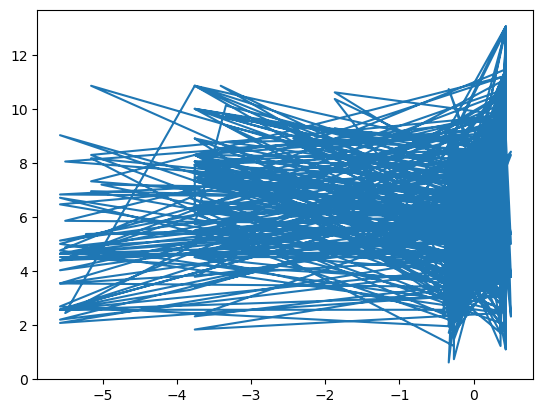

In [7]:
plt.plot(X_train[:,0],y_train)

# Plot Model Result

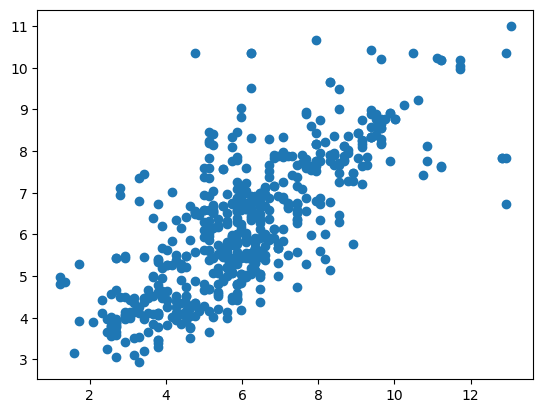

In [8]:
pickle.dump(gpr, open( "gpr_model.sav", "wb" ) )
plt.scatter(y_test, gpr.predict(X_test))

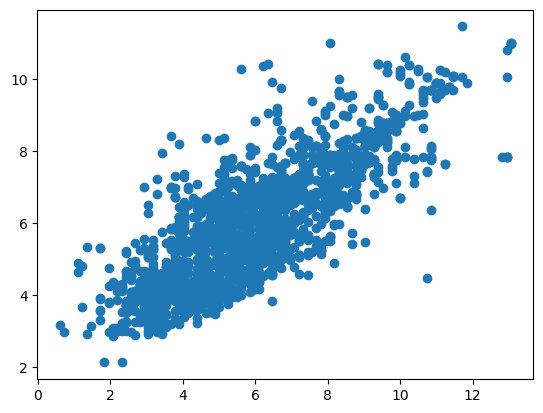

In [9]:
plt.scatter(y_train, gpr.predict(X_train))

# KL Divergance loss

In [10]:
from keras.losses import KLDivergence

In [11]:
kld=KLDivergence()

In [12]:
print("KLD loss: ", kld(y_train, gpr.predict(X_train)))

KLD loss:  tf.Tensor(-0.00023336081917071518, shape=(), dtype=float64)


2023-03-11 10:10:14.458749: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcuda.so.1'; dlerror: libcuda.so.1: cannot open shared object file: No such file or directory
2023-03-11 10:10:14.459055: W tensorflow/compiler/xla/stream_executor/cuda/cuda_driver.cc:265] failed call to cuInit: UNKNOWN ERROR (303)
2023-03-11 10:10:14.459084: I tensorflow/compiler/xla/stream_executor/cuda/cuda_diagnostics.cc:156] kernel driver does not appear to be running on this host (malick): /proc/driver/nvidia/version does not exist


# Crossentropy Loss

In [13]:
cross=keras.losses.categorical_crossentropy(y_train, gpr.predict(X_train))

In [14]:
print("Crossentropy Loss: ",cross)

Crossentropy Loss:  tf.Tensor(
[5.24701572e-07 6.46725193e-07 3.29463778e-07 ... 7.68748815e-07
 5.61308658e-07 9.88391333e-07], shape=(2270,), dtype=float64)


# Itakura-saito divergance

In [17]:
pred=gpr.predict(X_train)

In [34]:
div=float()
for i in range(len(pred)):
    div=div+((pred[0]/y_train[i])-np.log(pred[0]/y_train[i])-1)
div=div/len(pred)

In [39]:
div

array([0.09374975])